<a href="https://colab.research.google.com/github/mhmdsirajkhan/Customer_Segmentation_KMeans/blob/main/Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Found file: Advertising.csv

First 5 rows of data:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9

Generating graphs... (Check which line is steepest!)


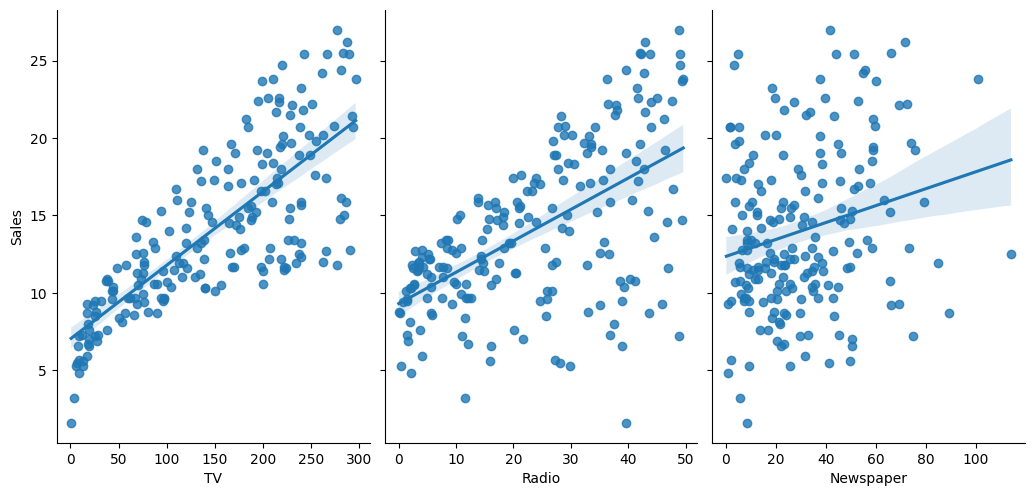

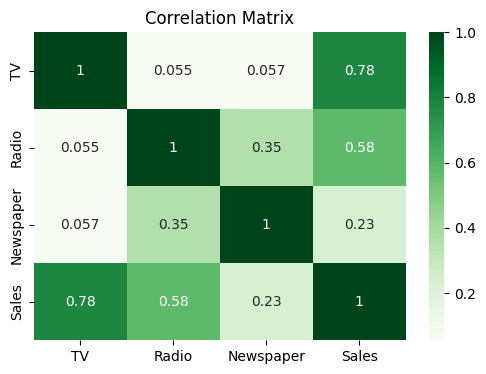

------------------------------
🎉 Model Performance (R2 Score): 0.90
------------------------------
Mean Squared Error: 3.17

What drives sales the most?
           Coefficient
TV            0.044730
Radio         0.189195
Newspaper     0.002761


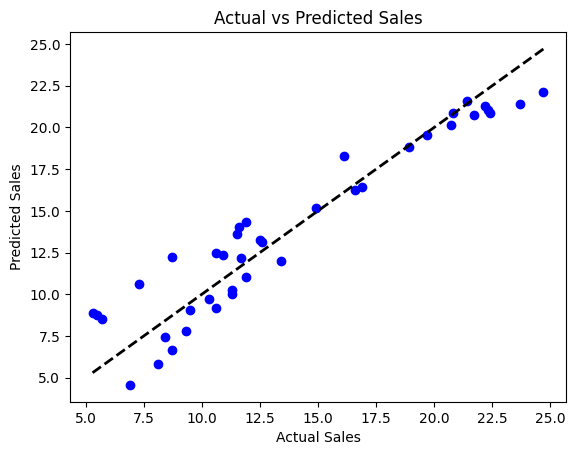

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import os

# --- STEP 1: LOAD THE FILE ---
# Automatically find the uploaded advertising file
csv_files = [f for f in os.listdir() if 'Advertising' in f and f.endswith('.csv')]

if len(csv_files) == 0:
    print("❌ Error: No file found. Please upload 'Advertising.csv'.")
else:
    filename = csv_files[0]
    print(f"✅ Found file: {filename}")
    df = pd.read_csv(filename)

    # --- STEP 2: CLEAN DATA ---
    # The file often has an extra index column called "Unnamed: 0", we should drop it
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])

    print("\nFirst 5 rows of data:")
    print(df.head())

    # --- STEP 3: VISUALIZE RELATIONSHIPS ---
    # Let's see which ad type drives the most sales
    print("\nGenerating graphs... (Check which line is steepest!)")
    sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=5, aspect=0.7, kind='reg')
    plt.show()

    # Heatmap to see the numbers
    plt.figure(figsize=(6,4))
    sns.heatmap(df.corr(), annot=True, cmap='Greens')
    plt.title("Correlation Matrix")
    plt.show()

    # --- STEP 4: TRAIN THE MODEL ---
    # X = Ad Budgets (TV, Radio, Newspaper)
    # y = Sales
    X = df[['TV', 'Radio', 'Newspaper']]
    y = df['Sales']

    # Split: 80% Training, 20% Testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Linear Regression Model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # --- STEP 5: EVALUATE ---
    predictions = model.predict(X_test)
    r2 = r2_score(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)

    print("-" * 30)
    print(f"🎉 Model Performance (R2 Score): {r2:.2f}")
    print("-" * 30)
    print(f"Mean Squared Error: {mse:.2f}")

    # --- STEP 6: INTERPRET RESULTS ---
    print("\nWhat drives sales the most?")
    coef_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
    print(coef_df)

    # Compare Actual vs Predicted
    plt.scatter(y_test, predictions, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    plt.xlabel('Actual Sales')
    plt.ylabel('Predicted Sales')
    plt.title('Actual vs Predicted Sales')
    plt.show()

In [7]:
# Let's predict sales for a specific marketing plan:
# TV Budget: $200
# Radio Budget: $40
# Newspaper Budget: $50
new_campaign = pd.DataFrame([[200, 40, 50]], columns=['TV', 'Radio', 'Newspaper'])

predicted_sales = model.predict(new_campaign)
print(f"💰 Projected Sales: {predicted_sales[0]:.2f} units")

💰 Projected Sales: 19.63 units
